# REINFORCE Agent

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from env import ForagingEnv

torch.manual_seed(0)
np.random.seed(0)

VARIANTS = ["V1", "V2", "V3"]
N_SEEDS = 5
N_EPISODES = 1000

## Policy Network

In [6]:
class PolicyNetwork(nn.Module):
    """
    Maps local observation -> softmax action probabilities.
    Two hidden layers of 64 units with ReLU activations.
    """

    def __init__(self, obs_size, n_actions, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)

    def select_action(self, obs):
        """Sample action and return (action, log_prob)."""
        obs_t = torch.FloatTensor(obs).unsqueeze(0)
        probs = self.forward(obs_t).squeeze(0)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)

## REINFORCE Training Loop

In [7]:
def compute_returns(rewards, gamma=0.99):
    """Compute discounted returns G_t for each timestep t."""
    G, returns = 0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns


def run_episode(env, policy):
    """Roll out one episode. Returns log_probs, rewards, food eaten."""
    obs = env.reset()
    log_probs, rewards = [], []
    done = False
    while not done:
        action, lp = policy.select_action(obs)
        obs, reward, done, info = env.step(action)
        log_probs.append(lp)
        rewards.append(reward)
    return log_probs, rewards, info["food_eaten"]


def train_reinforce(variant, seed, n_episodes=N_EPISODES,
                    gamma=0.99, lr=1e-3, print_every=200):
    """
    Train REINFORCE on a given variant and seed.

    Update rule:
        loss = -E[ (G_t - baseline) * log pi(a_t|s_t) ]
    where baseline = mean(G_t) over the episode.
    """
    env = ForagingEnv.make(variant, seed=seed)
    policy = PolicyNetwork(env.obs_size, env.n_actions)
    opt = optim.Adam(policy.parameters(), lr=lr)

    food_history = []

    for ep in range(1, n_episodes + 1):
        log_probs, rewards, food = run_episode(env, policy)

        returns = torch.FloatTensor(compute_returns(rewards, gamma))
        baseline = returns.mean()
        adv = returns - baseline
        if adv.std() > 1e-8:
            adv = adv / (adv.std() + 1e-8)

        log_probs_t = torch.stack(log_probs).squeeze(-1)
        loss = -(log_probs_t * adv).mean()

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        opt.step()

        food_history.append(food)

        if ep % print_every == 0:
            avg = np.mean(food_history[-print_every:])
            print(f"  [{variant}] seed={seed} ep={ep:4d} | "
                  f"avg food (last {print_every}): {avg:.1f}")

    return policy, food_history

## Train

In [8]:
results = {}   # variant -> (N_SEEDS, N_EPISODES)
policies = {}  # variant -> trained policy from seed 0

for variant in VARIANTS:
    print(f"\n=== {variant} ===")
    seed_results = []
    for seed in range(N_SEEDS):
        policy, food_hist = train_reinforce(variant, seed=seed)
        seed_results.append(food_hist)
        if seed == 0:
            policies[variant] = policy
    results[variant] = np.array(seed_results)

print("\nAll training complete.")


=== V1 ===
  [V1] seed=0 ep= 200 | avg food (last 200): 17.9
  [V1] seed=0 ep= 400 | avg food (last 200): 32.4
  [V1] seed=0 ep= 600 | avg food (last 200): 42.4
  [V1] seed=0 ep= 800 | avg food (last 200): 51.3
  [V1] seed=0 ep=1000 | avg food (last 200): 59.6
  [V1] seed=1 ep= 200 | avg food (last 200): 17.2
  [V1] seed=1 ep= 400 | avg food (last 200): 19.3
  [V1] seed=1 ep= 600 | avg food (last 200): 40.7
  [V1] seed=1 ep= 800 | avg food (last 200): 51.1
  [V1] seed=1 ep=1000 | avg food (last 200): 56.1
  [V1] seed=2 ep= 200 | avg food (last 200): 17.9
  [V1] seed=2 ep= 400 | avg food (last 200): 20.1
  [V1] seed=2 ep= 600 | avg food (last 200): 40.1
  [V1] seed=2 ep= 800 | avg food (last 200): 48.0
  [V1] seed=2 ep=1000 | avg food (last 200): 54.8
  [V1] seed=3 ep= 200 | avg food (last 200): 17.8
  [V1] seed=3 ep= 400 | avg food (last 200): 21.7
  [V1] seed=3 ep= 600 | avg food (last 200): 41.9
  [V1] seed=3 ep= 800 | avg food (last 200): 49.6
  [V1] seed=3 ep=1000 | avg food (last

## Plot Learning Curve

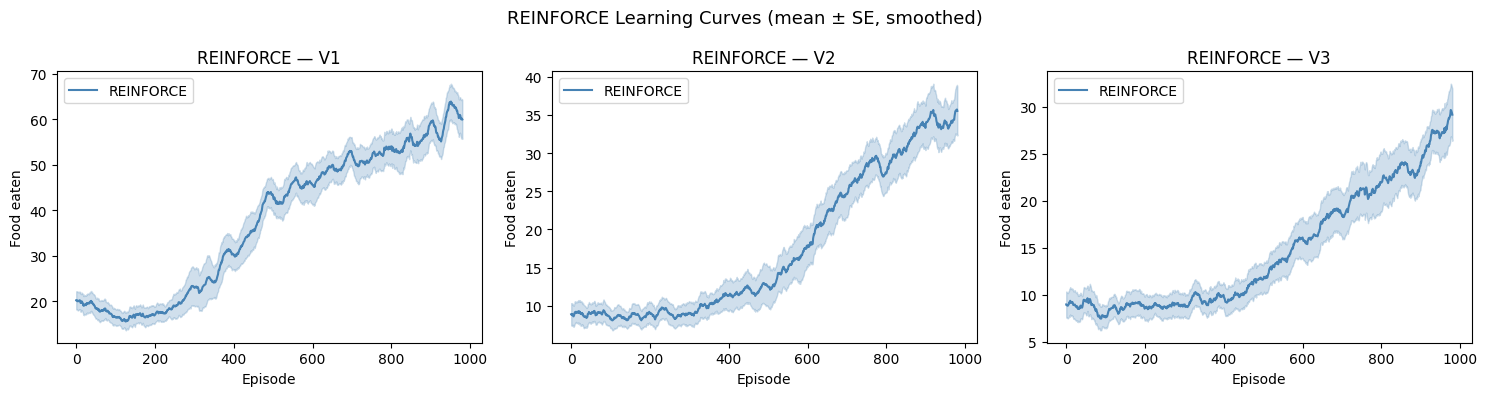

In [ ]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode="valid")


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, variant in zip(axes, VARIANTS):
    data = results[variant]
    mean = data.mean(axis=0)
    se = data.std(axis=0) / np.sqrt(N_SEEDS)

    ep = np.arange(len(smooth(mean)))
    ax.plot(smooth(mean), color="steelblue", label="REINFORCE")
    ax.fill_between(ep,
                    smooth(mean - se),
                    smooth(mean + se),
                    alpha=0.25, color="steelblue")
    ax.set_title(f"REINFORCE — {variant}")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Food eaten")
    ax.legend()

plt.suptitle("REINFORCE Learning Curves (mean ± SE, smoothed)", fontsize=13)
plt.tight_layout()
plt.savefig("reinforce_curves.png", dpi=150)
plt.show()

In [10]:
def episodes_to_threshold(food_hist, threshold_frac=0.8, window=20):
    """
    Return the first episode where the rolling mean food eaten
    reaches threshold_frac * final_performance.
    Returns N_EPISODES if threshold is never reached.
    """
    smoothed = smooth(food_hist, w=window)
    final_perf = smoothed[-1]
    threshold = threshold_frac * final_perf
    hits = np.where(smoothed >= threshold)[0]
    return hits[0] if len(hits) > 0 else len(food_hist)


print("Sample efficiency (episodes to 80% of final performance):")
print(f"{'Variant':<8} {'Mean':>8} {'Std':>8}")
for variant in VARIANTS:
    efficiencies = [
        episodes_to_threshold(results[variant][s])
        for s in range(N_SEEDS)
    ]
    print(f"{variant:<8} {np.mean(efficiencies):>8.0f} "
          f"{np.std(efficiencies):>8.0f}")

Sample efficiency (episodes to 80% of final performance):
Variant      Mean      Std
V1            541       60
V2            740       55
V3            814       86


In [11]:
np.save("reinforce_results.npy", results, allow_pickle=True)

for variant in VARIANTS:
    torch.save(policies[variant].state_dict(),
               f"reinforce_policy_{variant}.pt")

print("Saved reinforce_results.npy")
print("Saved reinforce_policy_V1/V2/V3.pt")

Saved reinforce_results.npy
Saved reinforce_policy_V1/V2/V3.pt


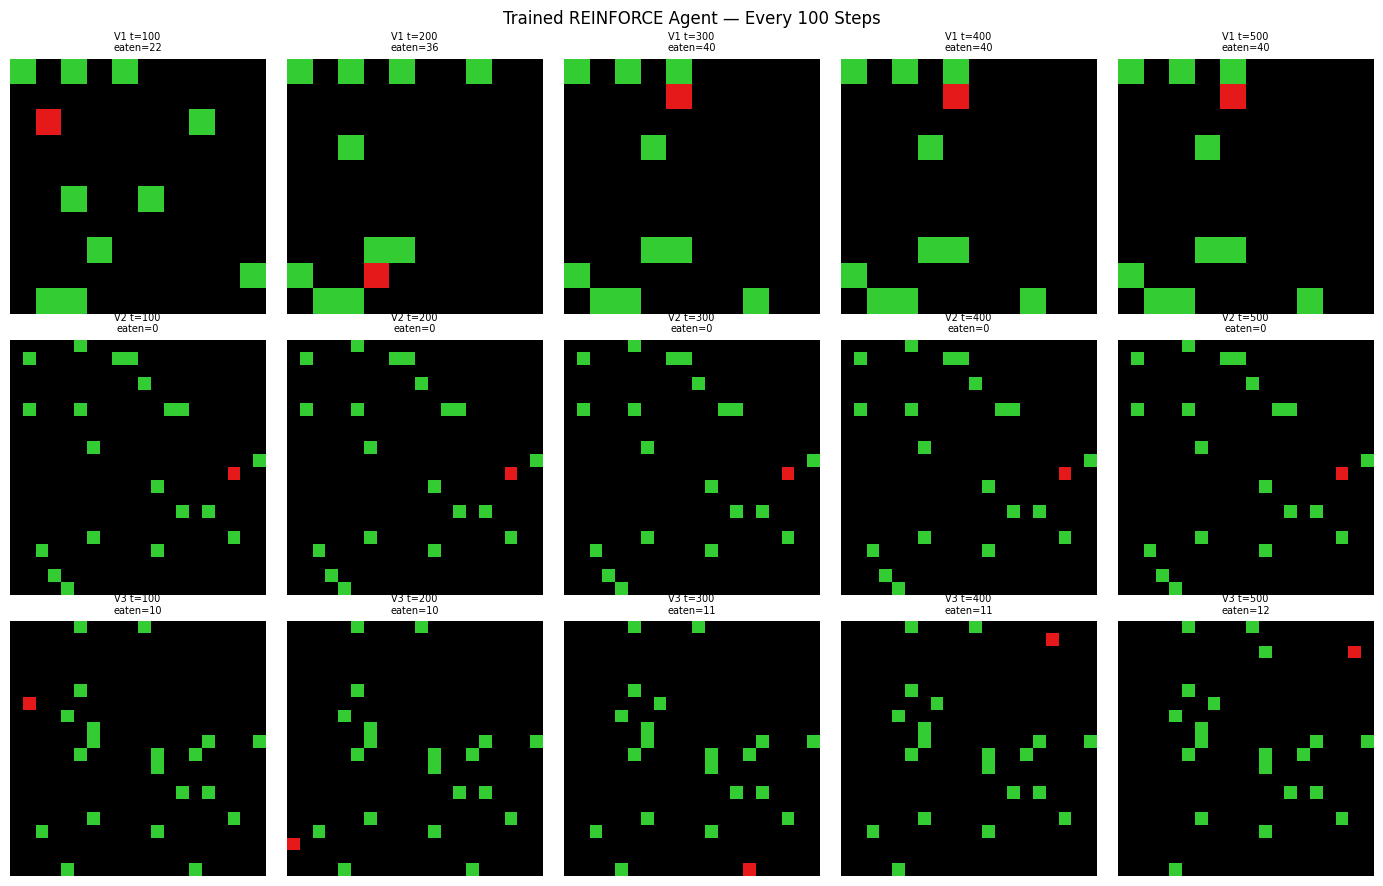

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))

for row, variant in enumerate(VARIANTS):
    env = ForagingEnv.make(variant, seed=99)
    obs = env.reset()
    done = False
    col = 0
    policy = policies[variant]

    with torch.no_grad():
        while not done and col < 5:
            obs_t = torch.FloatTensor(obs).unsqueeze(0)
            action = policy(obs_t).argmax().item()
            obs, _, done, info = env.step(action)
            if env.steps % 100 == 0:
                img = np.zeros((env.grid_size, env.grid_size, 3))
                for (r, c) in env.food_positions:
                    img[r, c] = [0.2, 0.8, 0.2]
                img[env.agent_pos[0], env.agent_pos[1]] = [0.9, 0.1, 0.1]
                axes[row][col].imshow(img, origin="upper")
                axes[row][col].set_title(
                    f"{variant} t={env.steps}\neaten={info['food_eaten']}",
                    fontsize=7)
                axes[row][col].axis("off")
                col += 1

plt.suptitle("Trained REINFORCE Agent — Every 100 Steps", fontsize=12)
plt.tight_layout()
plt.savefig("reinforce_behaviour.png", dpi=150)
plt.show()